In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("salesdaily.csv")
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

In [8]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [ ]:
df['datum'] = pd.to_datetime(df['datum'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   str           
dtypes: datetime64[us](1), float64(8), int64(3), str(1)
memory usage: 214.0 KB


In [39]:
Atc_Codes = df[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']]
drug_categories = Atc_Codes.sum().sort_values(ascending=False)
drug_categories

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

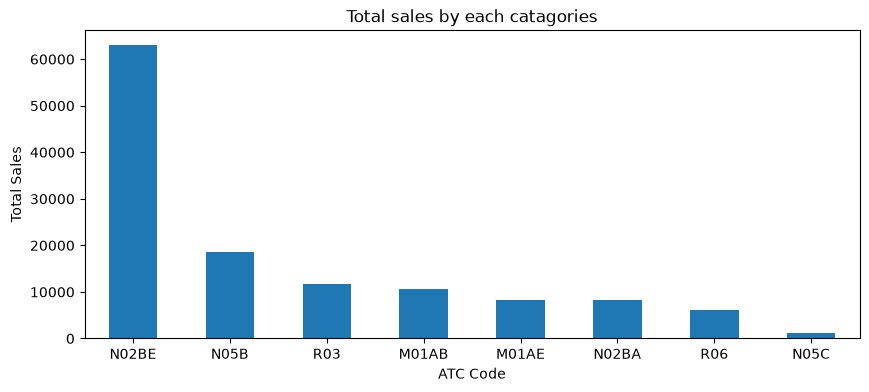

In [40]:
drug_categories.plot(kind="bar", figsize=(10,4))
plt.title("Total sales by each catagories")
plt.xlabel("ATC Code")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

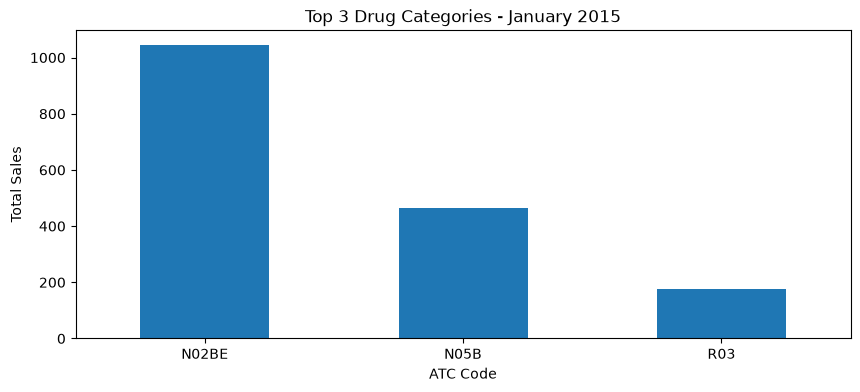

In [51]:
jan_2015 = df[(df['Month'] == 1) & (df['Year'] == 2015)]
jan_2015_sales = jan_2015[Atc_Codes.columns].sum().nlargest(3)
jan_2015_sales.plot(kind="bar", figsize=(10, 4))

plt.title("Top 3 Drug Categories - January 2015")
plt.xlabel("ATC Code")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

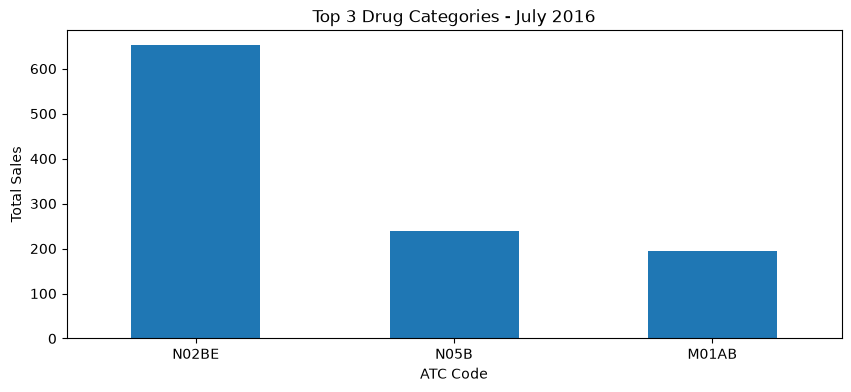

In [57]:
july_2016 = df[(df['Month'] == 7) & (df['Year'] == 2016)]
july_2016_sales = july_2016[Atc_Codes.columns].sum().nlargest(3)
july_2016_sales.plot(kind="bar", figsize=(10, 4))

plt.title("Top 3 Drug Categories - July 2016")
plt.xlabel("ATC Code")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

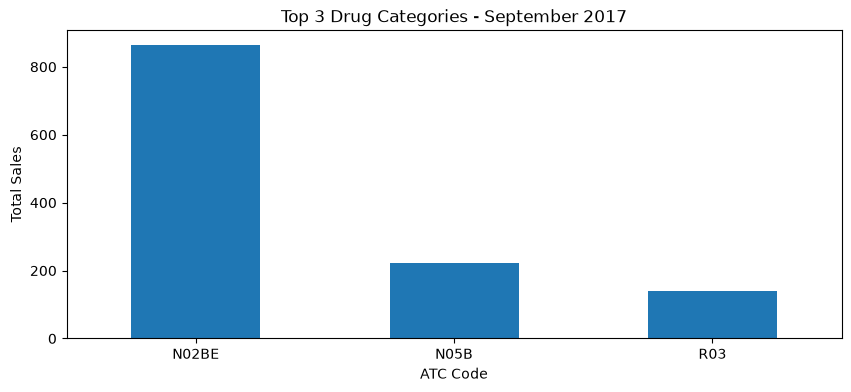

In [59]:
sept_2017 = df[(df['Month'] == 9) & (df['Year'] == 2017)]
sept_2017_sales = sept_2017[Atc_Codes.columns].sum().nlargest(3)
sept_2017_sales.plot(kind="bar", figsize=(10, 4))

plt.title("Top 3 Drug Categories - September 2017")
plt.xlabel("ATC Code")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [61]:
sales_2017 = df[df['Year'] == 2017][Atc_Codes.columns].sum().idxmax()
sales_2017

'N02BE'

In [68]:
highest_avg = df[Atc_Codes.columns].mean().idxmax()
highest_avg_val = df[Atc_Codes.columns].mean().max()
print(highest_avg)
print(highest_avg_val)


N02BE
29.917095303105413


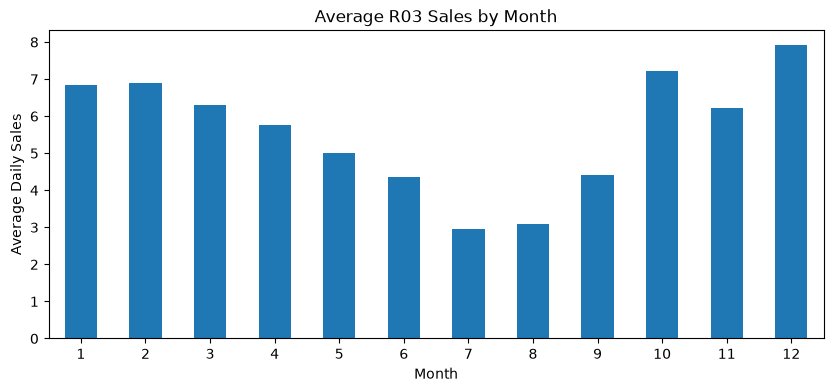

In [69]:
monthly_r03 = df.groupby("Month")["R03"].mean()
monthly_r03.plot(kind="bar", figsize=(10, 4))

plt.title("Average R03 Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=0)
plt.show()